# 基础流程
1. 理论框架：这个算法解决什么问题
2. 底层逻辑：它到底在优化什么
3. 数学表达：只讲比赛够用的公式
4. sklearn 实践：完整代码
5. 代码解读：每一段为什么这么写
6. 结果解读：指标、图像、模型表现
7. 常见错误：比赛中容易踩的坑
8. 算法标准模板：以后直接放进你的算法文档
9. 作业：巩固当天内容

# 线性回归

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes #导入数据集
from sklearn.model_selection import train_test_split #导入训练集测试集划分工具
from sklearn.linear_model import LinearRegression #导入线性回归模型
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score #导入评价指标：均方误差MSE，平均绝对误差MAE，R方

#1.加载数据
data=load_diabetes()
X=data.data
y=data.target

print("X shape:",X.shape)
print("y shape:",y.shape)
print("Feature names:",data.feature_names)

#2.转成DataFrame
X_df=pd.DataFrame(X,columns=data.feature_names)
y_series=pd.Series(y,name="target")

df=pd.concat([X_df,y_series],axis=1) #把 X_df 和 y_series 按列拼接起来

print(df.head())
print(df.describe())

#3.划分训练集和测试集
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)

#4.建立并训练模型
model = LinearRegression()

model.fit(X_train, y_train)

#5.查看模型参数
print("Intercept:", model.intercept_) #model.intercept_:截距
print("Coefficients:", model.coef_) #model.coef_:系数

coef_df = pd.DataFrame({
    "feature": data.feature_names,
    "coef": model.coef_
})

coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

print(coef_df)

#6.预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

#7.计算评价指标
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)

print("Train R2:", train_r2)
print("Test R2:", test_r2)


#8.可视化
#图一：真实值vs预测值
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_test_pred)

min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())

#完美预测线，斜率为 1 的线
plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted")
plt.show()

#图二：残差图
residuals = y_test - y_test_pred

plt.figure(figsize=(6, 5))
plt.scatter(y_test_pred, residuals)
plt.axhline(y=0, linestyle="--") #画一条 y=0 的水平线

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

#图三：系数图
plt.figure(figsize=(8, 5))
plt.barh(coef_df["feature"], coef_df["coef"]) #barh(y,x):水平条形图
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Linear Regression Coefficients")
plt.gca().invert_yaxis() #意思是把 y 轴反过来，让排序第一的特征显示在最上面
plt.show()

## 算法名称：线性回归 Linear Regression

一、适用任务
线性回归适用于回归问题，即目标变量为连续数值的预测任务，例如房价预测、销量预测、疾病进展预测、收入预测等。

二、核心思想
线性回归假设目标变量可以由多个特征的线性组合近似表示。模型通过学习各个特征对应的系数和截距，建立从特征 X 到目标 y 的映射关系。

三、数学形式
预测函数：
ŷ = w1x1 + w2x2 + ... + wpxp + b

其中，ŷ 为预测值，x1 至 xp 为特征，w1 至 wp 为特征系数，b 为截距。

四、优化目标
线性回归通过最小化真实值与预测值之间的残差平方和来估计参数：
min Σ(yi - ŷi)²

五、sklearn 实现
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

六、常用评价指标
MSE：平均平方误差，对大误差更敏感。
RMSE：均方根误差，与目标变量单位一致，更容易解释。
MAE：平均绝对误差，直观且对异常值不如 MSE 敏感。
R²：决定系数，用于衡量模型对目标变量波动的解释程度，最高为 1，也可能小于 0。

七、关键可视化
1. 真实值 vs 预测值图：观察预测结果是否接近理想 y=x 直线。
2. 残差图：观察残差是否随机分布在 0 附近，判断模型是否存在系统性误差。
3. 系数图：观察不同特征在线性模型中的方向和相对影响大小。

八、优点
1. 模型简单，训练速度快。
2. 可解释性强，适合作为 baseline。
3. 适合特征与目标近似线性关系的数据。
4. 便于分析特征与目标之间的预测关联。

九、缺点
1. 表达能力有限，难以刻画复杂非线性关系。
2. 对异常值较敏感。
3. 存在多重共线性时，系数可能不稳定。
4. 如果特征量纲不同，直接比较系数大小可能误导。

十、比赛使用建议
在线性回归用于比赛建模时，通常将其作为 baseline 模型。若线性回归表现较差，可以进一步尝试 Ridge、Lasso、决策树、随机森林、GBDT 等模型。报告中应同时展示训练集和测试集指标，并结合真实值-预测值图和残差图分析模型表现。解释系数时应谨慎，不能直接将预测关联解释为因果关系。

今天我完成了 diabetes 数据集上的线性回归建模。该任务属于回归问题，目标是根据 10 个特征预测疾病进展指标。线性回归假设目标变量可以由特征的线性组合近似表示，并通过最小化残差平方和学习模型的系数和截距。模型在训练集上的 RMSE 为 53.56，测试集上的 RMSE 为 53.85；训练集 R² 为 0.528，测试集 R² 为 0.453。结果说明模型没有明显过拟合，但整体预测能力一般，只能解释测试集中约 45.3% 的目标变量波动。True vs Predicted 图显示，散点整体沿 y=x 方向分布，但离虚线较分散，且模型对高真实值样本存在低估倾向。残差图显示残差大致围绕 0 分布，但存在少数大误差点。总体来看，线性回归适合作为 baseline，优点是简单、可解释，缺点是表达能力有限，对非线性关系和异常点较敏感。下一步可以学习 Ridge 和 Lasso，通过正则化提高模型稳定性和泛化能力。

# Ridge/Lasso与正则化

X shape: (442, 10)
y shape: (442,)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
results_df:
               model  train_rmse  test_rmse  train_mae   test_mae  train_r2  \
0  LinearRegression   53.558843  53.853446  43.483504  42.794095  0.527919   
1   Ridge_alpha_0.1   53.972063  53.446112  43.913006  42.996932  0.520607   
2     Ridge_alpha_1   58.208098  55.474462  48.805194  46.138858  0.442403   
3    Ridge_alpha_10   71.302076  66.662978  60.956061  58.030756  0.163322   
4  Lasso_alpha_0.01   53.638429  53.652208  43.549514  42.831847  0.526515   
5   Lasso_alpha_0.1   54.178024  52.897954  44.272664  42.854428  0.516941   
6     Lasso_alpha_1   62.134974  58.340172  52.958780  49.730328  0.364631   

    test_r2  coef_abs_mean  zero_coef_count  
0  0.452603     384.315951                0  
1  0.460852     207.953698                0  
2  0.419153     124.761888                0  
3  0.161226      33.991162                0  
4  0.456686     26

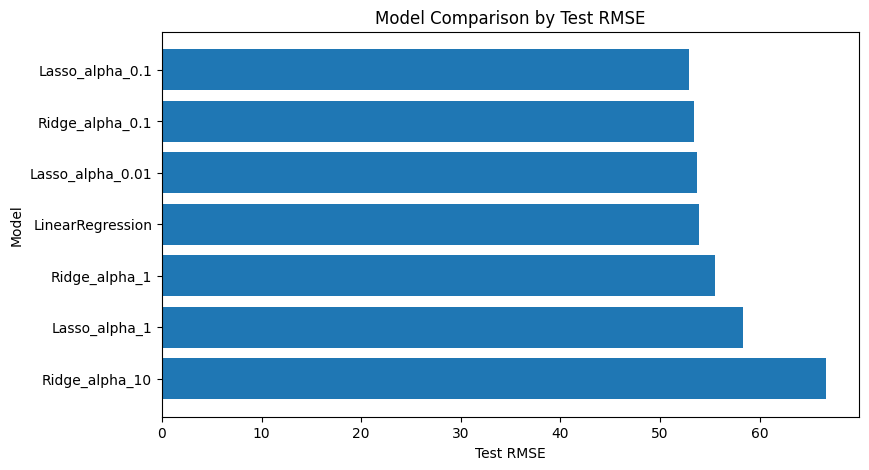

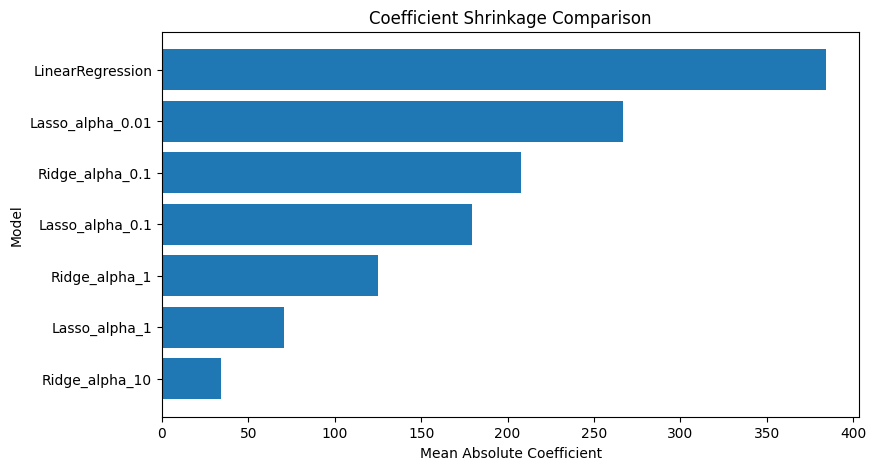

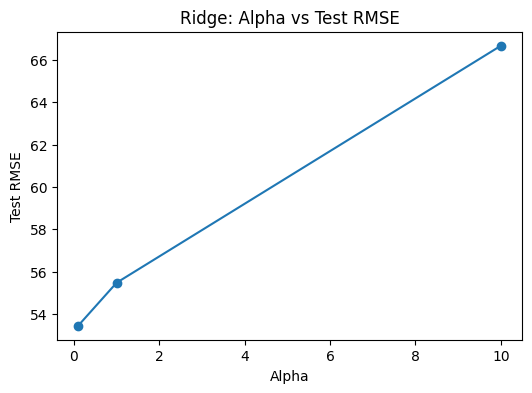

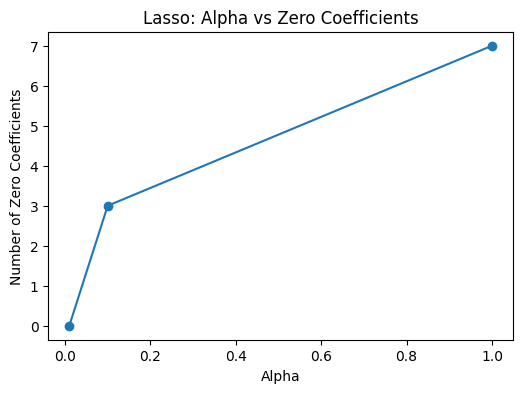

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso #Ridge：岭回归，L2正则化；Lasso：套索回归，L1正则化
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#1.加载数据
data = load_diabetes()

X = data.data
y = data.target

feature_names = data.feature_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature names:", feature_names)

#2.划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#3.建立多个模型
models = {
    "LinearRegression": LinearRegression(),
    "Ridge_alpha_0.1": Ridge(alpha=0.1),
    "Ridge_alpha_1": Ridge(alpha=1),
    "Ridge_alpha_10": Ridge(alpha=10),
    "Lasso_alpha_0.01": Lasso(alpha=0.01, max_iter=10000),#alpha=0.1：L1 正则化强度；max_iter=10000：最大迭代次数
    "Lasso_alpha_0.1": Lasso(alpha=0.1, max_iter=10000),
    "Lasso_alpha_1": Lasso(alpha=1, max_iter=10000)
}

#4.训练、预测、评价
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    #计算模型系数绝对值平均大小。Ridge/Lasso的核心就是压缩系数，如果正则化生效，通常alpha越大，coef_abs_mean越小
    coef_abs_mean = np.mean(np.abs(model.coef_)) #model.coed_:模型学到的所有系数
    #统计系数等于0的个数。Lasso的特点是可能把某些系数压成0，如果某个特征系数为0，则该特征被Lasso暂时排除在模型之外(Lasso的特征选择作用)
    zero_coef_count = np.sum(model.coef_ == 0) #统计系数等于0的个数

    results.append({
        "model": name,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "train_mae": train_mae,
        "test_mae": test_mae,
        "train_r2": train_r2,
        "test_r2": test_r2,
        "coef_abs_mean": coef_abs_mean, 
        "zero_coef_count": zero_coef_count
    })

results_df = pd.DataFrame(results)
print("results_df:\n",results_df)

#5.提取系数
coef_df = pd.DataFrame({
    "feature": feature_names
})

for name, model in models.items():
    coef_df[name] = model.coef_

print("coef_df:\n",coef_df)

#6.可视化诊断

#1.不同模型 Test RMSE 对比图(谁预测最好?)
# Test RMSE 越小，模型测试集误差越小；
# 排在最上面的模型表现最好；
# 如果 Ridge / Lasso 的 RMSE 小于 LinearRegression，说明正则化有提升。
plot_df = results_df.sort_values("test_rmse") #按照 test_rmse 从小到大排序

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(plot_df["model"], plot_df["test_rmse"])

ax.set_xlabel("Test RMSE")
ax.set_ylabel("Model")
ax.set_title("Model Comparison by Test RMSE")
#反转Y轴，RMSE最小的那个模型就会被移到图表的正上方（第一排）
ax.invert_yaxis()

plt.show()

#2.不同模型系数绝对值均值对比图(谁压缩系数更强?)
# 系数绝对值均值越小，说明模型系数整体越被压缩；
# Ridge / Lasso 的 alpha 越大，通常系数越小；
# 如果系数过小，可能出现欠拟合。
plot_df = results_df.sort_values("coef_abs_mean", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(plot_df["model"], plot_df["coef_abs_mean"])

ax.set_xlabel("Mean Absolute Coefficient")
ax.set_ylabel("Model")
ax.set_title("Coefficient Shrinkage Comparison")

ax.invert_yaxis()

plt.show()

#3.Ridge 不同 alpha 的 Test RMSE 曲线(Ridge 的 alpha 怎么影响误差?)
# alpha 改变后，测试集误差怎么变化；
# alpha 太小可能正则化不够；
# alpha 太大可能欠拟合；
# 最优 alpha 应该让测试集 RMSE 较低。
ridge_df = results_df[results_df["model"].str.contains("Ridge")].copy() #从 results_df 中筛选出 Ridge 模型

ridge_df["alpha"] = ridge_df["model"].str.extract(r"alpha_(.*)").astype(float) #从模型名字中提取 alpha

ridge_df = ridge_df.sort_values("alpha")

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(ridge_df["alpha"], ridge_df["test_rmse"], marker="o")

ax.set_xlabel("Alpha")
ax.set_ylabel("Test RMSE")
ax.set_title("Ridge: Alpha vs Test RMSE")

plt.show()

#4.Lasso 零系数数量图(Lasso 的 alpha 怎么影响特征选择?)
# alpha 越大，Lasso 越可能把更多系数压成 0；
# 零系数越多，模型越稀疏；
# 但如果太多特征被压成 0，可能欠拟合。
lasso_df = results_df[results_df["model"].str.contains("Lasso")].copy()

lasso_df["alpha"] = lasso_df["model"].str.extract(r"alpha_(.*)").astype(float)

lasso_df = lasso_df.sort_values("alpha")

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(lasso_df["alpha"], lasso_df["zero_coef_count"], marker="o")

ax.set_xlabel("Alpha")
ax.set_ylabel("Number of Zero Coefficients")
ax.set_title("Lasso: Alpha vs Zero Coefficients")

plt.show()

图一：谁预测最好？  
Lasso_alpha_0.1 的 Test RMSE 最小，说明在当前测试集划分下，它的预测误差最低。 

图二：谁压缩系数更强？   
LinearRegression 的系数绝对值均值最大；  
Ridge 和 Lasso 都压缩了系数；  
Ridge_alpha_10 和 Lasso_alpha_1 压缩最强。  

图三：Ridge 的 alpha 怎么影响误差？  
Ridge 中 alpha 从 0.1 增大到 10 后，Test RMSE 持续上升，说明 Ridge 正则化过强会使模型欠拟合。  

图 4：Lasso 的 alpha 怎么影响特征选择？  
Lasso 中 alpha 增大后，零系数数量从 0 增加到 7，说明 Lasso 正则化越强，筛掉的特征越多。

在本次实验中，Lasso_alpha_0.1 取得最低 Test RMSE，并且通过 L1 正则化将 3 个特征系数压缩为 0，实现了一定程度的特征选择。相比之下，Ridge_alpha_10 和 Lasso_alpha_1 正则化过强，系数被明显压缩，测试误差变大，表现出欠拟合倾向。

## 算法名称：Ridge 回归与 Lasso 回归

一、适用任务  
Ridge 和 Lasso 都适用于回归任务，尤其适用于线性回归中存在多重共线性、特征较多、模型系数不稳定或需要控制过拟合风险的场景。

二、核心思想  
普通线性回归只最小化训练误差，而 Ridge 和 Lasso 在训练误差基础上加入系数惩罚项，通过限制系数大小来降低模型复杂度，提高模型稳定性和泛化能力。

三、数学形式  
普通线性回归：  
min Σ(yi - ŷi)²

Ridge 回归：  
min Σ(yi - ŷi)² + αΣwj²

Lasso 回归：  
min Σ(yi - ŷi)² + αΣ|wj|

其中，α 是正则化强度。α 越大，对系数的惩罚越强。  

四、Ridge 与 Lasso 的区别  
Ridge 使用 L2 正则化，主要作用是压缩系数，使系数整体变小，但通常不会将系数压缩为 0。它适合处理多重共线性和希望保留大部分特征的情况。

Lasso 使用 L1 正则化，既可以压缩系数，也可能将部分系数压缩为 0，因此具有特征选择作用。它适合特征较多，并希望得到较稀疏模型的情况。

五、sklearn 实现  
from sklearn.linear_model import Ridge, Lasso  

ridge = Ridge(alpha=1)  
ridge.fit(X_train, y_train)  
ridge_pred = ridge.predict(X_test)  

lasso = Lasso(alpha=0.1, max_iter=10000)  
lasso.fit(X_train, y_train)  
lasso_pred = lasso.predict(X_test)  

六、关键参数  
alpha：正则化强度。alpha 越大，系数惩罚越强；alpha 过小接近普通线性回归，alpha 过大可能导致欠拟合。  
max_iter：Lasso 等迭代优化模型的最大迭代次数，用于避免模型未收敛。  

七、常用评价指标  
RMSE：衡量预测误差规模。  
MAE：衡量平均绝对误差。  
R²：衡量模型解释目标变量波动的能力。  
coef_abs_mean：观察系数整体大小，判断正则化是否压缩系数。  
zero_coef_count：观察 Lasso 是否产生稀疏解，即是否将部分特征系数压缩为 0。  

八、关键可视化  
1. 不同模型 Test RMSE 对比图：比较 LinearRegression、Ridge、Lasso 的预测误差。  
2. 系数绝对值均值对比图：观察正则化对系数大小的压缩效果。  
3. alpha 与 Test RMSE 曲线：观察正则化强度变化对模型泛化表现的影响。  
4. Lasso 零系数数量图：观察 Lasso 的特征选择效果。  

九、优点  
Ridge 的优点是能缓解多重共线性，提高模型稳定性，并保留所有特征。   
Lasso 的优点是能产生稀疏系数，具有特征选择能力，便于模型解释。  

十、缺点  
Ridge 不能直接进行特征选择，所有特征通常都会保留。  
Lasso 在特征强相关时可能不稳定，可能随机选择其中一个相关特征。  
二者都依赖 alpha 的选择，alpha 不合适会导致正则化不足或欠拟合。  

十一、比赛使用建议  
Ridge 和 Lasso 常用于线性回归 baseline 的改进版本。建模时应先与普通 LinearRegression 比较，再通过验证集或交叉验证选择合适的 alpha。报告中应说明正则化项的作用，并结合 RMSE、R²、系数变化和零系数数量解释模型表现。不要简单认为正则化越强越好。